## __`CS : Compressed Sensing of Images`__
 - ce notebook explore l’acquisition comprimée (compressed sensing) d’images naturelles,
 - en évaluant plusieurs modèles de parcimonie des coefficients dans une base d’ondelettes, 
 - afin d’améliorer la qualité de reconstruction à partir d’un nombre réduit de mesures.
La théorie du "compressed sensing" / "sparsity", revêt l’idée mathématique qui stipule que :  
 - l'on peut reconstruire un signal à partir de beaucoup moins de mesures que sa dimension, 
 - à condition qu’il soit parcimonieux ou sparse c-a-d que la plupart de ses coefficients sont nuls dans une base adaptée.
#### _`Sparsity`_ 
$$\Large x = \Psi.m \text{ <=> } \Large m = \Psi^{-1}.x$$
- $x$ signal sparse parcimonieux dont la plupart des composantes sont nulles ou négligeables.
- $\Psi$ transforme le signal $m$ en représentation parcimonisante sparse $x$ (ondelettes, Fourier, etc,).
- $m\in R^N$ signal (image, son, etc.)
- $\Psi^{-1}$ opérateur inverse qui reconstruit $m$ à partir de $x$.

#### _`Cadre de base`_
On observe un **signal** $m \in \mathcal{R}^N$ `via des mesures linéaires` $y = A.m$ 
- N dimension du signal (longueur du vecteur ou nombre de pixels)
- M nombre de mesures (nombre de lignes de A)
- où $A \in \mathcal{R}^{M \times N}$ est une matrice de mesure et $M \ll N$.
- $y\in R^M$ vecteur de mesures 
On dit que le système est sous‑déterminé, car il existe une infinité de $m$ compatibles avec $y$.


#### _`Rôle de la parcimonie`_
La parcimonie permet de sélectionner, parmi toutes les solutions, la représentation la plus « rare » $x$ : 
- $\min_{x} \|x\|_0 \text{ sous la contrainte } y = A \Psi^{-1} x.$ 
Ce problème en $\ell_0$ est combinatoire, on le remplace par 
- $\min_{x} \|x\|_1\text{ sous } y = A \Psi^{-1} x$ qui est convexe, sous hypothèses appropriées sur $A$ (incohérence, RIP)

La minimisation en norme $\ell_1$ permet de retrouver la solution parcimonieuse, même lorsque $M \ll N$.
- l’astuce de CS est d’ajouter l’hypothèse de parcimonie sur le signal, 
- on suppose qu’il admet une représentation $x = \Psi.m$, dans une base ou dictionnaire $\Psi$, 
- $x$ est K‑parcimonieux, si le vecteur $x$ ne possède qu'un petit nombre $K$ de coefficients non nuls, 
- tel qu'écrit $x = \Psi.\alpha$ avec $\alpha$ ayant peu de coefficients significatifs dans une base $\Psi$.

#### `Intuition pour les images naturelles`
Pour une image $m$, on prend souvent $x = \Psi \alpha$ avec $\Psi$ base d’ondelettes, car :
- les images naturelles ont des coefficients d’ondelettes qui décroissent vite avec l’échelle.  
- elles sont bien approchées par un **petit nombre** de coefficients significatifs (bords, contours),
- donc $\alpha$ est parcimonieux ou compressible. 
`De ce fait l'on peut:`
1. Mesurer directement $y = A.m$ avec $M \ll N$.  
2. Reconstruire $\hat m$ en résolvant un problème de minimisation $\ell_1$ sur les coefficients ondelettes. 
##### __`Synthèse`__
On cherche à reconstruire un signal $x∈R^N$ à partir d’un nombre de mesures linéaires $M≪N$, données par $y=Ax$. 
_`La clé est l’hypothèse de parcimonie suppose que:`_ 
- $x$ est sparse ou compressible dans une base adaptée, c-a-d qu’il peut s’écrire $x=\Phi\alpha$ 
- avec un vecteur de coefficients $\alpha$ comportant peu de composantes significatives. 
- sous des hypothèses appropriées sur la matrice de mesure $A$ (incohérence, propriété de type RIP),
- on peut retrouver $x$ en résolvant un problème de minimisation de norme $\ell_1$ sur les coefficients $\alpha$, 
- permettant une reconstruction fidèle malgré un sous‑échantillonnage important.

In [1]:
import sys, os
import numpy as np
toolbox_parent = r"/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle"
sys.path.insert(0, toolbox_parent)

from nt_toolbox.general import *
from nt_toolbox.signal import *
import nt_toolbox as nt

%matplotlib inline
%load_ext autoreload
%autoreload 2

#### `Filtre "pass-bas" mesures linéaires`
`Utiliser les mesures d'un filtre "pass-bas" pour retirer les basses fréquences de l'image`.
 - les images naturelles ne sont pas seulement parcimonieuses dans le domaine des ondelettes. 
 - elles présentent également une décroissance rapide des coefficients au fil des échelles. 
 - la graine d'ondelette grossières (passe-bas) concentrent une grande partie de l’énergie de l’image.
 - il est donc pertinent de mesurer directement les coefficients "pass-bas"
`Opérationnellement : `
 - cela revient à appliquer une décomposition en ondelettes, 
 - à extraire les coefficients d’approximation de niveau grossier, 
 - on met à zéro les coefficients $C_A$ d'approximation issus du passe‑bas.
 - puis à annuler ces coefficients lors de la reconstruction pour obtenir une image sans basses fréquences. » 

Maintenant nous chargeons une image $m \in \mathcal{R}^{n^2}$ de $n \times n$ pixels.

(512, 512)


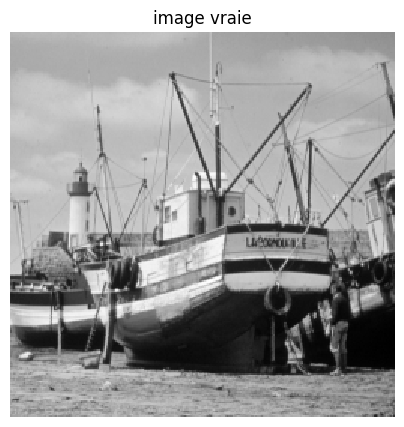

In [2]:
path= '/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_IMGCMPT/TP23_Imagerie_Computationnelle/'
name = path + 'nt_toolbox/data/boat.bmp'
n = 512

f0 = load_image(name,n)          # f0.shape = (256, 256)
f0 = (f0 - f0.min()) / (f0.max() - f0.min() + 1e-12)
print(f0.shape)

from skimage.transform import rescale

f0= rescale(f0, scale=0.5, anti_aliasing=True)   # par ex. moitié moins grand
plt.figure(figsize=(5, 5))
imageplot(clamp(f0),'image vraie')

`Raccourci pour les transformés en ondelettes` $\{ \langle f, \Psi_m \rangle \}_m$
- Nous calculons la transformée jusqu'à l'échelle $J$ de sorte que seuls les sous-bandes $k_0$ sont transformées.
- Les coefficients d’ondelettes sont des produits scalaires entre le signal et des “briques” de base.

Définition de $P$ opérateur de projection passe‑bas sur l’espace d’approximation d’échelle J en fonction des coefficients d’approximation ondelettes $\Phi_{J,k}$ :
-  $P_f=\sum_k⟨f,\Phi_{J,k} ⟩\Phi_{J,k})$ et son lien avec ton code wavedec2 

Mathématiquement, nous avons une décomposition du type : 
- $\large f(t) = \sum_{k} cA_J[k]\,\phi_{J,k}(t) + \sum_{j=1}^{J} \sum_{k} cD_j[k]\,\psi_{j,k}(t)$

  - où $\Phi_{J,k}$ sont les fonctions d’échelle et $\Psi_{j,k}$ les ondelettes.
  - le premier bloc concatèné correspond à cA_J (approximation grossière).
  - les blocs suivants sont cD_1, cD_2, ..., cD_J (détails de plus en plus grossiers suivant l'ordre).
  - sert à fixer la plus petite échelle (ou niveau minimal) de la transformée en ondelettes, 
  - c’est‑à‑dire jusqu’où on descend dans les décompositions en résolution.

`Que représente un coefficient`
Pour chaque échelle J et la position k :
- $\Phi_{J,k}(t)$ : une fonction d’échelle (low-pass) centrée près de la position k, à l’échelle grossière J.
- $\Psi_{j,k}(t)$ : une ondelette (petite oscillation localisée) à l’échelle J et position k.

Avec Discrete Wavelet Transform 1D, les coefficients [cA_J, cD_J, cD_{J-1}, ..., cD_1] obtenus ont pour signification : 
`cA_J :` 
- coefficients d’approximation au niveau le plus grossier J. 
- ce sont les projections du signal sur les fonctions d’échelle (low-pass), 
- donc le contenu “lent”, les grandes structures / tendance globale.

`cD_j :` 
- coefficients de détail au niveau j. 
- ce sont les projections sur les ondelettes à l’échelle $2^j$, 
- donc le contenu “rapide” autour de cette échelle, variations locales, détails, singularités.

Intuition par niveau :
- `cD_1` : détails les plus fins (hautes fréquences, bruit, petits bords).
- `cD_2` : un peu plus grossier, etc.
- `cD_J` : détails relativement grossiers, structures un peu plus larges.
- `cA_J` : ce qui reste après avoir filtré tous ces détails, une version très lissée du signal.

#### `Transformée en ondelettes discrètes 2D directe et inverse` 

In [3]:
import pywt
import numpy as np

# perform_direct_wavelet_transf transformée directe est un opérateur qui prend une image f 
# et renvoie ses coefficients d’ondelettes.
def perform_direct_wavelet_transf(f,n,k0,wavelet):
    # par ex., à adapter à ce que fait options.wavelet
    w = pywt.Wavelet(wavelet)
    # 2D image : f is 2D array
    coeffs_ti_2d = pywt.wavedec2(f, wavelet=w, level=k0, mode='periodization')
    return coeffs_ti_2d

# perform_inverse_wavelet_transf l’opérateur inverse qui à partir des coefficients d’ondelettes, 
# reconstruit l’image, en appelant.
def perform_inverse_wavelet_transf(coeffs,wavelet):
    # 2D image : f is 2D array
    w = pywt.Wavelet(wavelet)
    f_rec = pywt.waverec2(coeffs, wavelet=w, mode='periodization')
    return f_rec

`Calculer la transformée en ondelette.`

In [4]:
wavelet='sym8'
k0=2

coeffs_ti_2d = perform_direct_wavelet_transf(f0,n,k0,wavelet)# [cA_J, (cH_J,cV_J,cD_J), ..., (cH_1,cV_1,cD_1)]
# Approximation au niveau le plus grossier
cA = coeffs_ti_2d[0]
print(f"cA_J : {cA.shape}, len(coeffs_ti_2d[1:] : {len(coeffs_ti_2d[1:])}), len(coeffs_ti_2d) : {len(coeffs_ti_2d)}\n")
# Détails : du niveau J jusqu'au niveau 1
for j, (cH, cV, cD) in enumerate(coeffs_ti_2d[1:], start=1):
    level = len(coeffs_ti_2d) - j   # juste pour numéroter J, J-1, ..., 1
    print(f"{j} Level {level}: cH_{level} {cH.shape}, cV_{level} {cV.shape}, cD_{level} {cD.shape}")

cA_J : (64, 64), len(coeffs_ti_2d[1:] : 2), len(coeffs_ti_2d) : 3

1 Level 2: cH_2 (64, 64), cV_2 (64, 64), cD_2 (64, 64)
2 Level 1: cH_1 (128, 128), cV_1 (128, 128), cD_1 (128, 128)


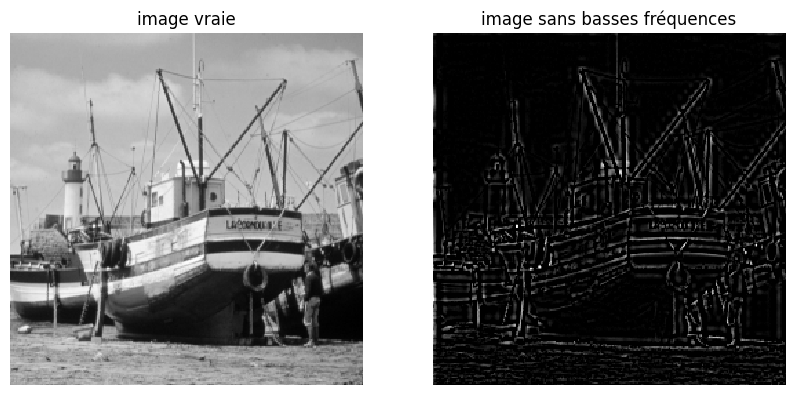

In [5]:
# Mise à zéro de cA (basses fréquences)
cA, details = coeffs_ti_2d[0], coeffs_ti_2d[1:]
cA_zero = np.zeros_like(cA)
coeffs_high = [cA_zero] + list(details)
f_vec = perform_inverse_wavelet_transf(coeffs_high,wavelet)
plt.figure(figsize=(10, 10))
imageplot(clamp(f0),'image vraie',[1,2,1])
imageplot(clamp(f_vec),'image sans basses fréquences',[1,2,2])

- LL = approximation → tons clairs uniformes (ciel, murs lisses)
- LH = contours verticaux  → hautes fréquences
- HL = contours horizontaux → hautes fréquences  
- HH = contours diagonaux   → hautes fréquences

On décompose l’image par ondelettes, ensuite nous annulons les coefficients d’approximation (passe‑bas), puis on reconstruit à partir des seuls coefficients de détail. Le résultat est une image où la composante basse fréquence a été retirée, ne laissant visibles que les structures de haute fréquence (contours, textures).

#### __`Exercice 1`__
Construire une approximation basse fréquence $∣f_{low}∣$ 
- Ne conserver que les coefficients passe‑bas, au nombre de $P=2^{2^J} =(n/k_0)^2$ : 
  - image est de taille $n×n$.
  - on travaille avec une décomposition ondelette 2D à $J=log2(n)−k0$ niveaux.
  - au niveau le plus grossier, le bloc basse fréquence (cA_J) est de taille $(n/2^{k_0})×(n/2^{k_0})$.
  - si on note $2^{k_0}=k_0$ => $(n/2^{k_0})×(n/2^{k_0}) \equiv (n/{k_0})^2$ => $P=2^{2^J} =(n/k_0)^2$
  - P correspond au nombre de coefficients passe‑bas utilisés pour construire $f_{low}$

P : 65536, cA.shape : (64, 64), 64*64 : 4096, f_low.shape : (256, 256)


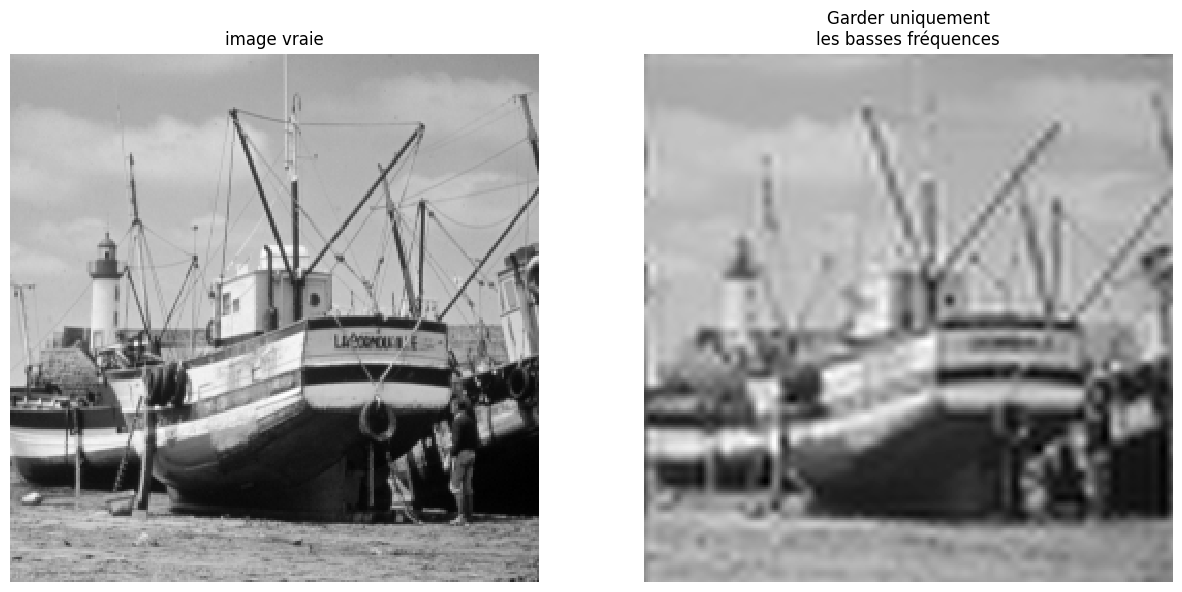

In [6]:
details_zero = [(np.zeros_like(cH), np.zeros_like(cV),np.zeros_like(cD)) for (cH, cV, cD) in details]
# P = cA.shape[0] * cA.shape[1] 
P = n**2 // 4  
coeffs_low = [cA] + details_zero
f_low = perform_inverse_wavelet_transf(coeffs_low,wavelet)
print(f"P : {P}, cA.shape : {cA.shape}, 64*64 : {64*64}, f_low.shape : {f_low.shape}")
plt.figure(figsize=(15, 15))
imageplot(clamp(f0),'image vraie',[1,2,1])
imageplot(clamp(f_low),f'Garder uniquement\nles basses fréquences',[1,2,2])


### `Mesures orthogonales aléatoires`.
- Considérons un opérateur "compressed sensing" qui correspond à une projection orthogonal randomisée.
- Extraire les coefficients d'ondelettes haute-fréquences $x_0 = \{ \langle f, \psi_m \rangle \}_{m \in I_0}$.
   - A est un masque $n×n$ rempli de 1.
   - on met à 0 le bloc supérieur gauche de taille $2^J×2^J$
   - A == 0 = zone low-pass, 
   - A == 1 = zone high-pass

<table border="1" style="border-collapse:collapse; text-align:center; font-family:monospace;">
  <tr>
    <td style="width:30px; height:30px;">0<br><small>LL</small></td>
    <td style="width:30px; height:30px;">1<br><small>LH</small></td>
    <td rowspan="2" style="width:60px; height:60px;">1<br><small>LH</small></td>
  </tr>
  <tr>
    <td style="width:30px; height:30px;">1<br><small>HL</small></td>
    <td style="width:30px; height:30px;">1<br><small>HH</small></td>
  </tr>
  <tr>
    <td colspan="2" style="width:60px; height:60px;">1<br><small>HL</small></td>
    <td style="width:60px; height:60px;">1<br><small>HH</small></td>
  </tr>
</table>
<div>
</div>

| Zone                                           | Valeur dans A | Rôle                             |
| ---------------------------------------------- | ------------- | -------------------------------- |
| Bloc $2^J \times 2^J$ en haut à gauche | 0             | Low-pass (exclus de $I_0$)    |
| Tout le reste                                  | 1             | High-pass (inclus dans $I_0​$) |

#### `Extrait du vecteur de coefficients d'ondelettes haute-fréquence` 
$$\large x_0={⟨f,ψ.m⟩}m∈I_0$$
- `pywt.coeffs_to_array` reconstruit l'image de coefficients (n x n) d'un coup et retourne : 
- `fw_img :`Recolle toutes les sous-bandes en une seule image 2D
- `slices :`Retourne les positions de chaque sous-bande dans fw_img

In [7]:
# Reconstruire l'image de coefficients (n x n) d'un coup
# fw_img — Recolle toutes les sous-bandes en une seule image 2D
# slices — Retourne les positions de chaque sous-bande dans fw_img
fw_img, slices = pywt.coeffs_to_array(coeffs_ti_2d)
s_low = slices[0]
low_h = s_low[0].stop
low_w = s_low[1].stop
print(f"low_h : {low_h}, low_w : {low_w}  => {low_h**2}")
A = np.ones((fw_img.shape))  
A[0:low_w,0:low_h] = 0
print(f"A.shape : {A.shape} => {A.flatten().shape}")
# retourne les indices de la matrice ou se trouvent les coefficients hautes fréquences
I0 = np.where(A.flatten()==1)[0]
print(f"I0.shape : {I0.shape} => len(I0)+low_h**2 : {len(I0)+low_h**2}")
print(f"Nombre de niveaux : {len(coeffs_ti_2d) - 1}, fw_img.shape : {fw_img.shape}, {fw_img.shape[0]*fw_img.shape[0]} , A.shape : {A.shape}, I0.shape : {I0.shape}")
x0 = fw_img.flatten()[I0]
print(f"Le nombre de coefficients haute fréquence est : {len(x0)} P = N // 4 : {P}")

low_h : 64, low_w : 64  => 4096
A.shape : (256, 256) => (65536,)
I0.shape : (61440,) => len(I0)+low_h**2 : 65536
Nombre de niveaux : 2, fw_img.shape : (256, 256), 65536 , A.shape : (256, 256), I0.shape : (61440,)
Le nombre de coefficients haute fréquence est : 61440 P = N // 4 : 65536


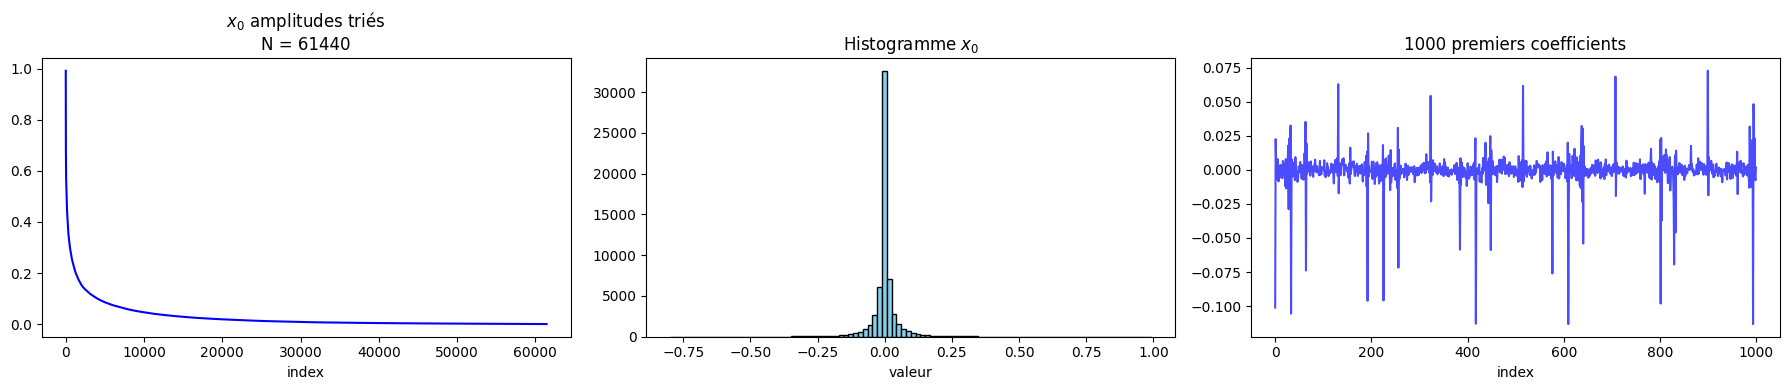

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Amplitudes triées
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ amplitudes triés\nN = {len(x0)}')
axes[0].set_xlabel('index')

# 2. Histogramme
axes[1].hist(x0, bins=100, color='skyblue', edgecolor='k')
axes[1].set_title(f'Histogramme $x_0$')
axes[1].set_xlabel('valeur')

# 3. Zoom sur les 1000 premiers
axes[2].plot(x0[:1000], 'b-', alpha=0.7)
axes[2].set_title(f'1000 premiers coefficients')
axes[2].set_xlabel('index')

plt.tight_layout()
plt.show()

- `Figure 1:` Amplitudes triées est la plus importante en Compressed Sensing car elle montre visuellement que peu de coefficients haute fréquence ont une grande amplitude (les premiers à gauche), la grande majorité des 61440 coefficients sont quasi nuls → Parcimonie confirmée : $x_0$ est bien sparse !

- `Figure 2:` Pic très marqué autour de 0 → la grande majorité des coefficients sont quasi nuls, confirmant la parcimonie vue dans la figure 1.

- `Figure 3:` Les coefficients oscillent autour de 0 avec quelques pics occasionnels. C'est typique des coefficients d'ondelettes où la plupart sont proches de 0, seuls quelques-uns (les contours de l'image) ont une amplitude significative.

#### `Nombre de mesures basses fréquences:` 
 - $P_0 = 2^{2J}=(n/2^{k_0})^2 $

In [9]:
P0 = (n/2**k0)**2
print(f"Le nombre de de mesures basse fréquence : {P0}")

Le nombre de de mesures basse fréquence : 16384.0


#### `Nombre de mesures CS (acquisition ou mesure comprimée)`
__Idée principale__
- En traitement du signal classique (théorème de Shannon-Nyquist), 
- il faut au moins autant de mesures que de coefficients pour reconstruire un signal : $P≥N$
_`Le Compressed Sensing dit`_ : 
- si le signal est parcimonieux (sparse), 
- c'est-à-dire que la plupart de ses coefficients sont nuls ou quasi-nuls, 
- alors on peut le reconstruire avec beaucoup moins de mesures : $P≪N$

In [10]:
P = 4 * P0
print(f"Le nombre de mesures CS : {P}")

Le nombre de mesures CS : 65536.0


##### __`Operateurs de permutations aléatoires`__ 
 - $S_1,S_2 : \mathcal{R}^N \rightarrow \mathcal{R}^N$ tel que $S_k(x)_i = x_{\sigma_k(i)}$ où $ \sigma_k \in \Sigma_N $ 
- soit une permutation aléatoire $\{1,\ldots,N\}$.

In [11]:
N = len(x0)   # 15360

# Deux permutations aléatoires sigma_1 et sigma_2
sigma1 = np.random.permutation(N)   # σ_1
sigma2 = np.random.permutation(N)   # σ_2

# Opérateurs directs
S  = lambda x,sigma: x[sigma]
# Opérateurs S_1 et S_2 appliqués à x0
S1_x0 = S(x0,sigma1)
S2_x0 = S(x0,sigma2)

##### __`Opérateurs adjoints ou inverses`__ 
 - $S_1^*,S_2^*$ (notés |$S_1^S, S_2^S|$) 
 - correspondant à la permutation inverse $\sigma_k^*$ tel que  $\sigma_k^* \circ \sigma_k(i)=i$.

In [12]:
# Permutations inverses (adjoints)
sigma1S = np.zeros(N, dtype=int)
sigma1S[sigma1] = np.arange(N)

sigma2S = np.zeros(N, dtype=int)
sigma2S[sigma2] = np.arange(N)

# Opérateurs inverses (adjoints)
Sinv = lambda x,sigS: x[sigS]

# Vérification S1* ∘ S1 = identité
print(np.allclose(Sinv(S(x0, sigma1), sigma1S), x0))   # True
print(np.allclose(Sinv(S(x0, sigma2), sigma2S), x0))   # True

True
True


x (vecteur N coefficients high-pass)
    ↓  S1 : permutation aléatoire σ1
    S1(x)
    ↓  C : transformée DCT
    C(S1(x))
    ↓  S2 : permutation aléatoire σ2
    S2(C(S1(x)))
    ↓  ↓_P : garder seulement les P premières entrées
    y = Φx  (vecteur de P mesures)

##### __`Opérateur CS (acquisition ou mesure comprimée):`__ $ \Phi:\mathcal{R}^N \rightarrow \mathcal{R}^P$ 
Une projection sur des atomes aléatoires correspond aux vecteurs colonnes de la matrice de mesure: 
- $ \Phi=[\Phi_1,\Phi_2,…,\Phi_N]$
 - $\Phi x = \begin{pmatrix} \langle x, \phi_1 \rangle & \langle x, \phi_2 \rangle & \cdots & \langle x, \phi_P \rangle \end{pmatrix}^\top$
 - $ (\Phi x)_i = \langle{x}{\Phi_{\sigma_2(i)}}\rangle $ 
   - ou $ \Phi_i $ est une base orthogonale mélangée (scrambled) : $ \Phi_i(x) = \large c_i( \sigma_1(x) ) $
   - où $\{ c_i \}_i$ est la base orthogonale DCT (Transformée en Cosinus Discrète).
`Cette opérateur peut s'écrire sous une forme compacte :` 
 - $ \Phi x = ( S_2 \circ C \circ S_1 (x) ) \downarrow_P $
   - où $S_1,S_2$ sont les opérateurs de permutation, 
   - et $\downarrow_P$ sélectionne les $P$ premières entrées du vecteur.

Phi(x) = dP( S2( C( S1(x) ) ) )
                         ↓
      S1(x) : permutation σ1
                         ↓
      C(…)  : DCT orthogonale
                         ↓
      S2(…) : permutation σ2
                         ↓
      dP(…) : garder les P premiers  →  y ∈ R^P

In [13]:
from scipy.fft import dct, idct

P = N // 4   # nombre de mesures Shanon-Nyquist 
print(f" N : {N} P : {P}")
# DCT orthogonale et son inverse
C     = lambda x: dct(x, norm='ortho')  # transformée en cosinus discrete dans une base orthogonale
Cinv  = lambda x: idct(x, norm='ortho') # transformée en cosinus discrete inverse dans une base orthogonale
dP    = lambda x: x[:P] # Sous-échantillonnage ↓_P : garder les P premières entrées
Phi   = lambda x: dP(S(C(S(x,sigma1)),sigma2)) # Opérateur Φ : R^N → R^P

 N : 61440 P : 15360


- $\large x_0 = \{ \langle f, \psi_m \rangle \}_{m \in I_0}$ => coefficients d'ondelettes haute-fréquences
- $\Phi(x0)$ => l'opérateur Compress Sensing d'acquisition ou de mesures comprimées

In [14]:
# opérateur d'acquisition ou de mesures comprimées
y = Phi(x0)
print(f"x0.shape : {x0.shape}")       # (N,)  = (15360,)
print(f"y.shape  : {y.shape}")        # (P,)  = (3840,)

x0.shape : (61440,)
y.shape  : (15360,)


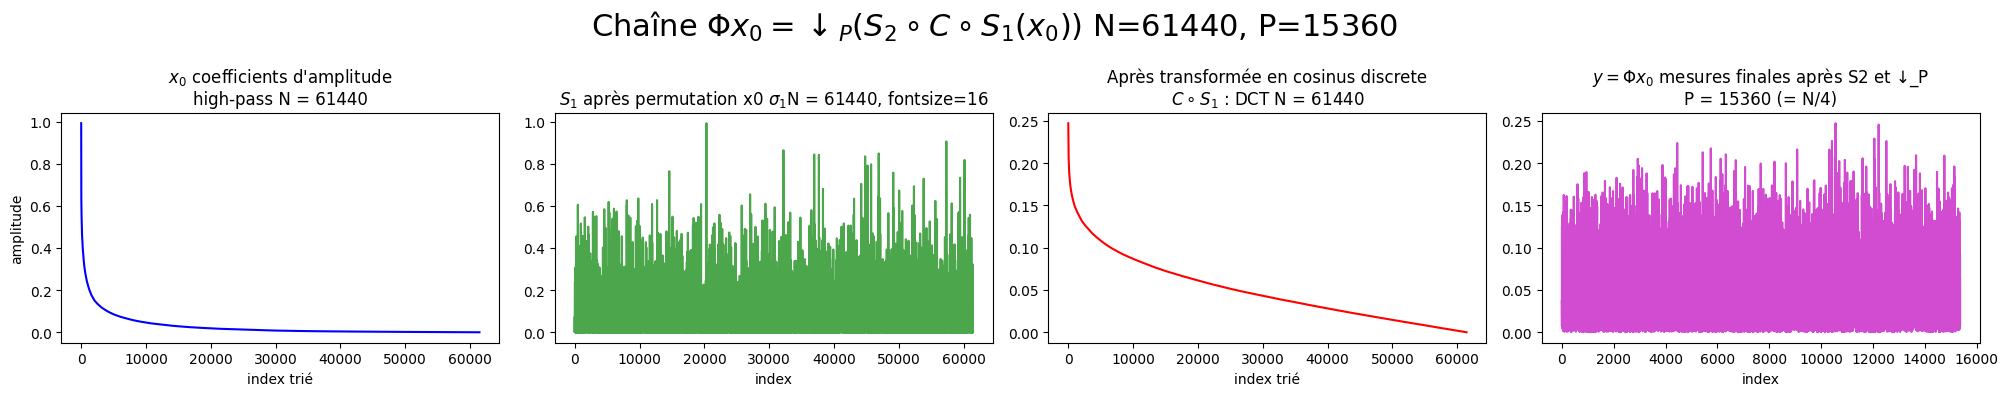

Nombre de coefficient haute fréquence : 61440
Nombre de mesures finales : 15360


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# 1. x0 : coefficients high-pass originaux
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ coefficients d\'amplitude\nhigh-pass N = {N}')
axes[0].set_xlabel('index trié')
axes[0].set_ylabel('amplitude')

# 2. Après S1 : permutation sigma1
S1_x0 = S(x0, sigma1)
axes[1].plot(np.abs(S1_x0), 'g-', alpha=0.7)
axes[1].set_title(f'$S_1$ après permutation x0 $\\sigma_1$N = {N}, fontsize=16')
axes[1].set_xlabel('index')

# 3. Après C∘S1 : DCT
CS1_x0 = C(S1_x0)
axes[2].plot(np.sort(np.abs(CS1_x0))[::-1], 'r-')
axes[2].set_title(f'Après transformée en cosinus discrete\n$C \\circ S_1$ : DCT N = {N}')
axes[2].set_xlabel('index trié')

# 4. y = Φx0 : mesures finales après S2 et ↓_P
axes[3].plot(np.abs(y), 'm-', alpha=0.7)
axes[3].set_title(f'$y = \\Phi x_0$ mesures finales après S2 et ↓_P\nP = {P} (= N/4)')
axes[3].set_xlabel('index')

plt.suptitle(f'Chaîne $\\Phi x_0 = \\downarrow_P(S_2 \\circ C \\circ S_1(x_0))$'f' N={N}, P={P}', fontsize=22)
plt.tight_layout()
plt.show()

print(f"Nombre de coefficient haute fréquence : {x0.shape[0]}")   # (N,)
print(f"Nombre de mesures finales : {y.shape[0]}")    # (P,)

- `Figure 1:` Amplitudes triées est la plus importante en Compressed Sensing car elle montre visuellement que peu de coefficients haute-fréquence ont une grande amplitude (les premiers à gauche), la grande majorité des 61440 coefficients sont quasi nuls → Parcimonie confirmée : $x_0$ est bien sparse!

- `Figure 2:` Les coefficients sont mélangés aléatoirement par la permutation $\sigma_1$. L'amplitude totale est conservée (même norme), mais l'ordre est perdu. C'est une étape de scrambling pour que l'information soit répartie uniformément avant la DCT.

- `Figure 3:` DCT concentre l'énergie, quelques coefficients ont une grande amplitude (à gauche) et le reste est quasi nul. La DCT est une base adaptée qui compresse encore mieux l'information que la base ondelette originale. C'est ce qui rend les mesures très efficaces.

- `Figure 4:` Les P = N/4 => 15360 mesures finales. Chaque valeur est le produit scalaire entre $x_0$ et un atome aléatoire. L'amplitude est distribuée uniformément entre toutes les mesures grâce au mélange $S_2 \circ C \circ S_1$. On a réduit N=61440 → P=15360 coefficients tout en préservant l'information essentielle.


_`Rappel :`_
- $x_0 = \{ \langle f, \psi_m \rangle \}_{m \in I_0}$ => coefficients d'ondelettes haute-fréquences
- $\Phi(x0)$ => l'opérateur Compress Sensing d'acquisition ou de mesures comprimées
_`L'opérateur adjoint est :`_ 
 - $ \Phi^* x = S_1^* \circ C^* \circ S_2^* (x\uparrow_P) $ 
 - `où` $\uparrow_P$ `ajoute N-P zéros à la fin d'un vecteur` 
 - et $C^*$ est la transformée cosinus discrète inverse.

In [16]:
# Φ* : R^P → R^N
uparrow = lambda x,N,P: np.concatenate([x, np.zeros(N - P)])
# L'opérateur adjoint 
PhiS  = lambda x,N,P: Sinv(Cinv(Sinv(uparrow(x,N,P), sigma2S)),sigma1S)

Effectuer les mesures de compressed sensing Perform CS (sans bruitage).

In [17]:
# l'opérateur d'acquisition de mesures
y = Phi(x0)
# L'opérateur adjoint 
z = PhiS(y,N,P)
print(f"phiS.shape : {z.shape},\nz : {z}")

phiS.shape : (61440,),
z : [-0.0771674   0.00768448  0.00459172 ...  0.02810322 -0.03223685
 -0.02770865]


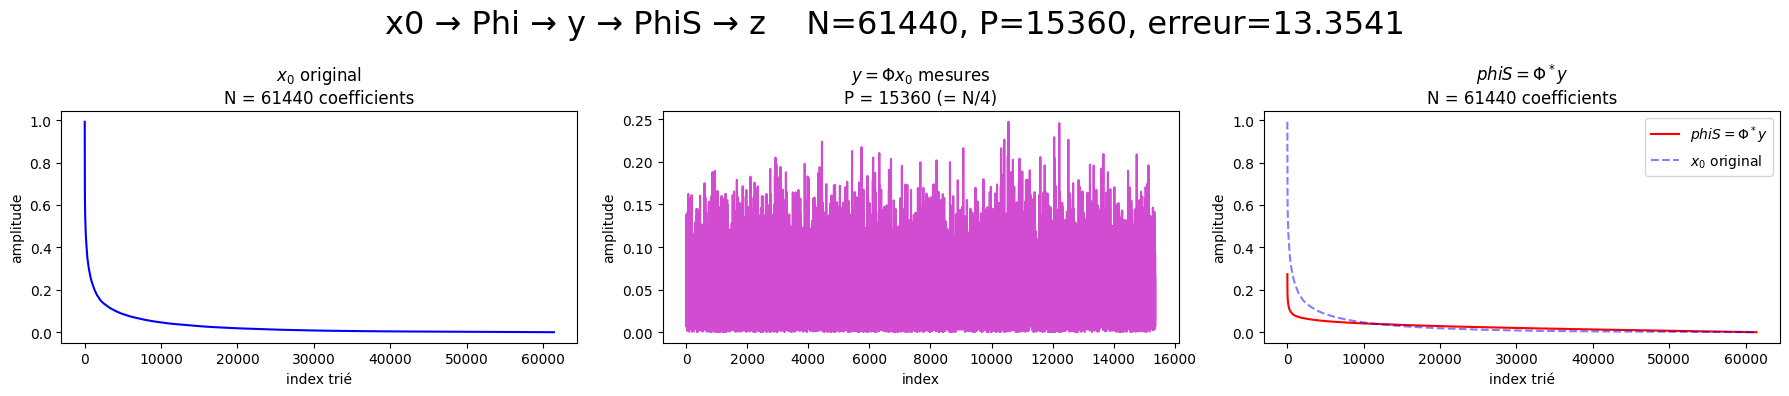

x0.shape          : (61440,)
y.shape           : (15360,)
z.shape           : (61440,)
||phiS - x0||     : 13.354145
||x0||            : 15.416959
erreur relative   : 0.866198


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. x0 original
axes[0].plot(np.sort(np.abs(x0))[::-1], 'b-')
axes[0].set_title(f'$x_0$ original\nN = {N} coefficients')
axes[0].set_xlabel('index trié')
axes[0].set_ylabel('amplitude')

# 2. y = Φx0 : mesures
axes[1].plot(np.abs(y), 'm-', alpha=0.7)
axes[1].set_title(f'$y = \\Phi x_0$ mesures\nP = {P} (= N/4)')
axes[1].set_xlabel('index')
axes[1].set_ylabel('amplitude')

# 3. z = Φ*y : reconstruction
axes[2].plot(np.sort(np.abs(z))[::-1], 'r-', label='$phiS = \\Phi^* y$')
axes[2].plot(np.sort(np.abs(x0))[::-1], 'b--', alpha=0.5, label='$x_0$ original')
axes[2].set_title(f'$phiS = \\Phi^* y$\nN = {N} coefficients')
axes[2].set_xlabel('index trié')
axes[2].set_ylabel('amplitude')
axes[2].legend()

# ← suptitle simplifié sans \xrightarrow
erreur = np.linalg.norm(z - x0)
plt.suptitle(f'x0 → Phi → y → PhiS → z    N={N}, P={P}, erreur={erreur:.4f}', fontsize=23)
plt.tight_layout()
plt.show()

# Vérification numérique
print(f"x0.shape          : {x0.shape}")
print(f"y.shape           : {y.shape}")
print(f"z.shape           : {z.shape}")
print(f"||phiS - x0||     : {np.linalg.norm(z - x0):.6f}")
print(f"||x0||            : {np.linalg.norm(x0):.6f}")
print(f"erreur relative   : {np.linalg.norm(z - x0) / np.linalg.norm(x0):.6f}")

#### __`Pseudo inverse de Moore-Penrose`__
__La pseudo-inverse de Moore-Penrose, propriété fondamentale est :__ 
- $\Phi+=(\Phi^∗\Phi)^{−1}\Phi^∗$
__On considère un opérateur de compressed sensing :__ 
- $\Phi = \downarrow_P \circ \underbrace{\left(S_2 \circ C \circ S_1\right)}_{\text{orthogonal } U}=\downarrow_P \circ U$
__Pourquoi__ $\Phi^+ = \Phi^*$: 
 - $\Phi = \downarrow_P \circ S_2 \circ C \circ S_1$
 - $\Phi^∗=S_1^∗ \circ C^∗ \circ S_2^ \circ \uparrow_P$
 - $\Phi\Phi^∗= \downarrow_P (\circ S_2 \circ C \circ S_1) \circ (S_1^∗ \circ C^∗ \circ S_2^∗ \circ)\uparrow_P$
 - $\Phi\Phi^∗ = \downarrow_P \circ \underbrace{S_2 \circ C \circ S_1 \circ S_1^∗ \circ C^∗ \circ S_2^∗}_{=I}\circ\uparrow_P$ = $\downarrow_P \circ \uparrow_P=I_p$
__Calcul de__ $\Phi \Phi^*$ 
- on a : $\Phi \Phi^*= (\downarrow_P \circ U) \circ (U^* \circ \downarrow_P^*)= \downarrow_P \circ U U^* \circ \downarrow_P^*.$
 - comme $U$ est orthogonal ($U^* U = I$) : $\Phi \Phi^*= \downarrow_P \circ I \circ \downarrow_P^* = \downarrow_P \circ \downarrow_P^*$
__Donc__ : $ ΦΦ^∗ = I_P ⇒ Φ^+ = Φ^∗$
#### __`Exercice 2`__
- L'égalité $\Phi^+ y =\Phi^* y$ repose sur la notion de pseudo-inverse de Moore-Penrose permettant la  reconstruction d'une image. 
- Pour une matrice $\Phi \in \mathbb{R}^{P \times N}$, la pseudo-inverse $\Phi^+$ définie la solution du problème $min_x ||x||_2$ sous contrainte $\Phi_x=y$
- L'égalité $\Phi^+ = \Phi^*$ est valable car $\Phi$ est construit à partir d'opérations orthogonales (permutations + DCT orthogonale), 

x_rec.shape : (61440,)


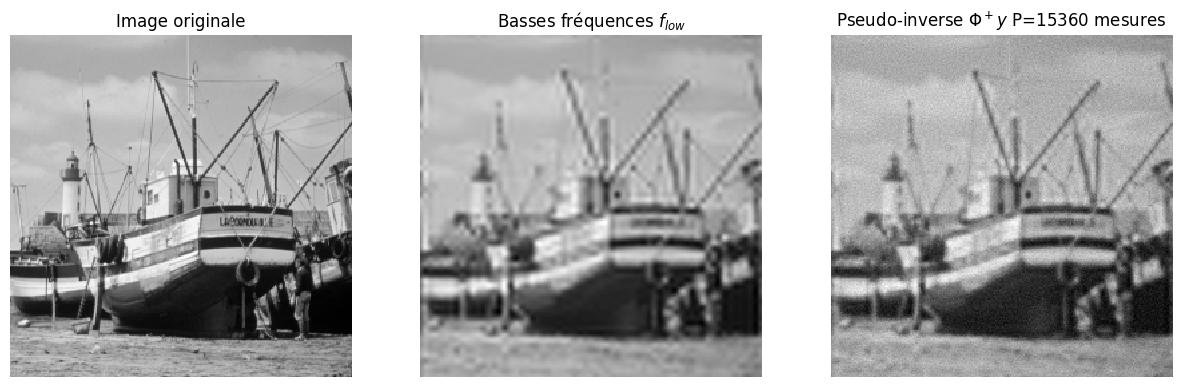

In [19]:
# opérateur d'acquisition de mesures Φ
y = Phi(x0)
x_rec = PhiS(y,N,P)

print(f"x_rec.shape : {x_rec.shape}")  # (N,)

J = int(np.log2(n) - k0)
A = np.ones((fw_img.shape))  
A[0:low_h, 0:low_w] = 0

# retourne les indices de la matrice ou se trouvent les coefficients hautes fréquences
I0 = np.where(A.flatten()==1)[0]

# 3. Reconstruire l'image complète
fw_rec = fw_img.flatten().copy()
fw_rec[I0] = x_rec                   # replacer les coefficients high-pass

fw_rec_2d = fw_rec.reshape(fw_img.shape)

# Reconstruire depuis les coefficients d'ondelettes
coeffs_rec = pywt.array_to_coeffs(fw_rec_2d, slices, output_format='wavedec2')
f_rec = pywt.waverec2(coeffs_rec, wavelet=wavelet, mode='periodization')

# 4. Affichage
plt.figure(figsize=(15, 5))
imageplot(clamp(f0),    'Image originale',                           [1, 3, 1])
imageplot(clamp(f_low), r'Basses fréquences $f_{low}$',               [1, 3, 2])
imageplot(clamp(f_rec), f'Pseudo-inverse $\Phi^+ y$ P={P} mesures', [1, 3, 3])
plt.show()

- `Figure 1 : Image nette,` avec tous les détails contours nets, textures visibles
- `Figure 2 : Image floue,` contours lissés, détails perdus, seule l'enveloppe générale est visible
- `Figure 3 : Image bruitée,` structure reconnaissable mais granuleuse, contours visibles mais bruités

`Interprétation :` 
- Reconstruction par pseudo-inverse $\Phi^+ y = \Phi^* y$ avec P = 3840 mesures, 25% des N = 15360 coefficient HF. 
- La structure du bateau est reconnaissable, ce qui montre que l'information essentielle a été capturée. 
- Mais il y a du bruit car la pseudo-inverse $\Phi^*$ est une reconstruction naïve qui ne tient pas compte de la parcimonie de $x_0$.


### __`Reconstruction par CS via le schéma de Douglas-Rachford`__
_`Principe`_
Ce problème favorise les solutions parcimonieuses (sparse) `grâce à la norme` $\ell^1$, ce qui permet de retrouver $x_0$ exactement même avec beaucoup moins de mesures que de coefficients.
- $x_0$ les coefficients hautes fréquences,
- $\Phi$ = opérateur d'extration de mesures (Compress Sensing)
- $\Phi^*$ = adjoint (ou transposé) 
- $y = \Phi x_0$ mesures parcimonieuses 
- $\Phi^+$ = pseudo-inverse de Moore-Penrose

À partir des mesures parcimonieuses $y = \Phi x_0$ 
- où $\Phi \in \mathbb{R}^{P \times N}$ avec $P \ll N$, 
- on cherche à reconstruire le signal original $x_0 \in \mathbb{R}^N$ en résolvant le problème de minimisation :
- $min_{x \in \mathbb{R}^N}||x||_1$ `sous contrainte` $\Phi_x = y $
__Propriété fondamentale de la pseudo-inverse de Moore-Penrose:__ 
- $\Phi+=(\Phi^∗\Phi)^{−1}\Phi^∗$ => $ ΦΦ^∗ = I_P ⇒ Φ^+ = Φ^∗$
__Dans notre cas :__ $\Phi^⁺$ = $\Phi^*$
- Car les lignes de $\Phi$ sont orthonormales ($\Phi\Phi^*$ = I)
- Donc la pseudo-inverse coïncide avec l'adjoint
__`Décomposition du problème`__
Le problème est de la forme $\min_x F(x) + G(x)$ avec :
- $F(x) = \iota_{\mathcal{C}}(x)$ => fonction indicatrice de $\mathcal{C} = {x \mid \Phi x = y}$ (vaut 0 si la contrainte est satisfaite, $+\infty$ sinon)
- $G(x) = |x|_1$ => norme $\ell^1$ qui favorise la parcimonie
__`Schéma de Douglas-Rachford`__
L'algorithme itère les deux opérateurs proximaux dans l'ordre inverse :

$ \begin{cases} x_{k+1} = \text{prox}_{\gamma G}(z_k) \\ z_{k+1} = z_k + \mu(\text{prox}_{\gamma F}(2x_{k+1 }-z_k) - x_{k + 1}) \end{cases}$
 - où :
   - $\text{prox}_{\gamma G}$ seuillage doux => $\text{prox}_{\gamma G}(x)_i = \text{sign}(x_i) \cdot \max(|x_i| - \gamma, 0)$
   - $\text{prox}_{\gamma F}$ projection sur $\mathcal{C}$ => $\text{prox}_{\gamma F}(x) = x + \Phi^*(y - \Phi x)$
   - $\gamma > 0$ pas de régularisation
   - $\mu \in (0, 2)$ paramètre de relaxation

##### __`Exercice 3:`__ 
Implémenter les opérateurs proximal et proximal réfléchi de F (projecteur orthogonal sur $\mathcal{C}$) et $G$ (seuillage doux)
- On essaie de retrouver $x_0$ 
- à partir des mesures $y = \Phi x_0$, 
- et $y$ contient P = N/4  =>  c.a.d. 25% des coefficients de $x_0$.
__Problème initial :__
- $x_0 \in R^N$    = 61440 coefficients ondelettes haute fréquence de l'image
- $y \in R^P$     = 15360 mesures (seulement 25% de N !)
  - `On ne connaît QUE y, pas x0`
  - `On veut retrouver x0 à partir de y`
__Comment on vérifie ?__
Dans le contexte du TP (exceptionnelle) on connaît $x_0$ donc on peut comparer la reconstruction avec l'original.  
   - $\text{prox}_{\gamma G}$ seuillage doux => $\text{prox}_{\gamma G}(x)_i = \text{sign}(x_i) \cdot \max(|x_i| - \gamma, 0)$
   - $\text{prox}_{\gamma F}$ projection sur $\mathcal{C}$ => $\text{prox}_{\gamma F}(x) = x + \Phi^*(y - \Phi x)$

In [20]:
# Paramètres
gamma = .1
mu    = 1.5

print(f"Le nombre de coefficients haute fréquence de x0 est : 15360")
# Opérateurs proximaux
prox_G  = lambda x,gamma: np.sign(x) * np.maximum(np.abs(x) - gamma, 0)  # seuillage doux
prox_F  = lambda x,y,N,P: x + PhiS((y - Phi(x)),N,P) 

Le nombre de coefficients haute fréquence de x0 est : 15360



Résultat final x.shape : (61440,)
Fidélité aux mesures ||Φx - y|| : 0.000001
On compare ||x||₁ = 960.620274 avec x0 =>||x - x0|| : 11.154583


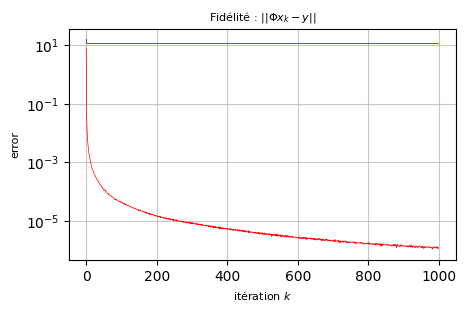

In [ ]:
# Itérations Douglas-Rachford
z = np.zeros(N)
errors = []
diff = []
niter = 200000
#
y = Phi(x0) 
#
for k in range(niter):
    # seuillage doux    
    x = prox_G(z,gamma) 
    # x est la reconstruction parcimonieuse de x0       
    z = z + mu * (prox_F((2*x - z),y,N,P) - x) # mise à jour
    # Affichage du progrès
    if k % 100 == 0:
        err = np.linalg.norm(Phi(x) - y)
        diff.append(np.linalg.norm(x - x0))
        errors.append(err)
        #print(f"  iter {k:4d} : ||Φx - y|| = {err:.6f}, ||x||₁ = {np.sum(np.abs(x)):.6f}")

print(f"\nRésultat final x.shape : {x.shape}")  # (N,) = (61440,)
print(f"Fidélité aux mesures ||Φx - y|| : {np.linalg.norm(Phi(x) - y):.6f}")  # doit → 0
print(f"On compare ||x||₁ = {np.sum(np.abs(x)):.6f} avec x0 =>||x - x0|| : {np.linalg.norm(x - x0):.6f}")      # erreur de reconstruction
plt.figure(figsize=(5,3))
plt.plot(errors, 'r-', linewidth=.5)
plt.plot(diff, 'b-', linewidth=.5)
plt.title(f'Fidélité : $||\\Phi x_k - y||$',fontsize=8)
plt.xlabel('itération $k$',fontsize=8)
plt.ylabel('error',fontsize=8)
plt.grid(True, alpha=0.7)
plt.yscale('log')

In [ ]:
# Comparaison avec la pseudo-inverse
x_rec = PhiS(y,N,P)
# Comparaison
print("\nComparaison Douglas-Rachford vs Pseudo-inverse \n")
print(f"||x_DR  - x0||    = {np.linalg.norm(x - x0):.6f}")     # Douglas-Rachford
print(f"||x_rec - x0||    = {np.linalg.norm(x_rec - x0):.6f}") # Pseudo-inverse
print(f"\nGain DR vs Φ*   = {np.linalg.norm(x_rec-x0) / np.linalg.norm(x-x0):.2f}x (>1 signifie que Douglas Rachford est meilleur)")

# Normalisé par ||x0||
print(f"\nErreur relative Douglas-Rachford = {np.linalg.norm(x-x0)/np.linalg.norm(x0):.4f}")
print(f"Erreur relative Pseudo-inverse Moore-Penrose => Φ* = {np.linalg.norm(x_rec-x0)/np.linalg.norm(x0):.4f}")


Comparaison Douglas-Rachford vs Pseudo-inverse 

||x_DR  - x0||    = 11.154583
||x_rec - x0||    = 13.354145

Gain DR vs Φ*   = 1.20x (>1 signifie que Douglas Rachford est meilleur)

Erreur relative DR  = 0.7235
Erreur relative Φ*    = 0.8662


### __`Exercice 4`__

Implement the DR iterative algorithm.
Keep track of the evolution of the $\ell^1$ norm $G(x_k)$.

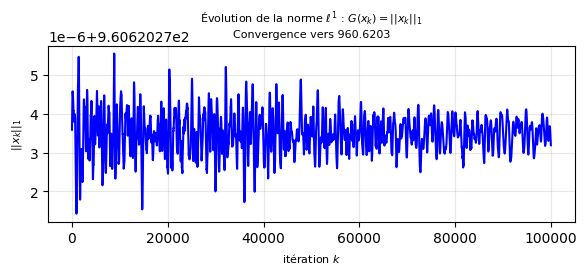

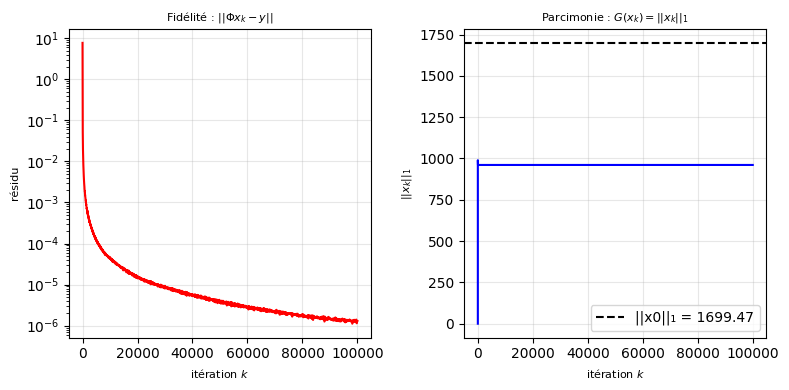

In [31]:
# Stocker la norme L1 à CHAQUE itération
L1_history = []           # liste vide pour stocker les valeurs

for k in range(niter):
    x = prox_G(z,gamma)
    z = z + mu * (prox_F((2*x - z),y,N,P) - x)
    
    L1_history.append(np.sum(np.abs(x)))   # ← stocker G(x_k) = ||x||₁
    
    #if k % 100 == 0:
        #print(f"iter {k:4d} : ||Φx-y|| = {np.linalg.norm(Phi(x)-y):.6f}, ||x||₁ = {L1_history[-1]:.6f}")

# Tracer l'évolution de ||x||₁
plt.figure(figsize=(6, 3))
plt.plot(L1_history, 'b-', linewidth=1.5)
plt.title(f'Évolution de la norme $\\ell^1$ : $G(x_k) = ||x_k||_1$\n'
          f'Convergence vers {L1_history[-1]:.4f}', fontsize=8)
plt.xlabel('itération $k$', fontsize=8)
plt.ylabel('$||x_k||_1$', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tracer les deux courbes (fidélité + parcimonie)
fig, axes = plt.subplots(1, 2, figsize=(8,4))

# 1. Fidélité aux mesures
residu_history = []
z = np.zeros(N)
for k in range(niter):
    x = prox_G(z,gamma)
    z = z + mu * (prox_F((2*x - z),y,N,P) - x)
    residu_history.append(np.linalg.norm(Phi(x) - y))

axes[0].plot(residu_history, 'r-', linewidth=1.5)
axes[0].set_title(f'Fidélité : $||\\Phi x_k - y||$', fontsize=8)
axes[0].set_xlabel('itération $k$', fontsize=8)
axes[0].set_ylabel('résidu', fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# 2. Parcimonie (norme L1)
L1_history = []
z = np.zeros(N)
for k in range(niter):
    x = prox_G(z,gamma)
    z = z + mu * (prox_F((2*x - z),y,N,P) - x)
    L1_history.append(np.sum(np.abs(x)))

axes[1].plot(L1_history, 'b-', linewidth=1.5)
axes[1].set_title(f'Parcimonie : $G(x_k) = ||x_k||_1$', fontsize=8)
axes[1].set_xlabel('itération $k$', fontsize=8)
axes[1].set_ylabel('$||x_k||_1$', fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=np.sum(np.abs(x0)), color='k', linestyle='--', 
                label=f'||x0||₁ = {np.sum(np.abs(x0)):.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

`Figure 1: `
 - Le graphe montre la convergence de la norme $\ell^1$ au cours des itérations de Douglas-Rachford. 
 - Douglas-Rachford est un schéma de point fixe, pas une descente de gradient. 
 - La séquence $(x_k)$ n'est pas monotone mais converge quand même vers la solution. 
 - Les oscillations autour de 960 prouvent que l'algorithme explore l'espace des solutions avant de se stabiliser.

#### __`Exercice 5`__
Afficher l'image reconstruite à partir des P0 mesures et des P mesures CS, le nombre total de mesures utilisées est P+P0.

   - Mesures basse fréquence :  $P0 = (n/2^{k0})^2$  (coefficient LL de l'image ondelette)
   - Mesures haute fréquence :  $P  = N/4$         (mesures CS via Douglas-Rachford)

Total mesures utilisées :  $P+P0$

In [ ]:
# =================================================================
# Exercice 5 : Reconstruction combinée P0 (linéaire) + P (CS)
# =================================================================

# 1. P0 : coefficients basse fréquence (mesures linéaires)
# Les coefficients du bloc LL sont directement mesurés
P0 = cA.shape[0] * cA.shape[1]   # = (n/2^k0)² = (256/4)² = 4096
print(f"n : {n}, k0 : {k0},  cA.shape : {cA.shape[0]**2}, (n/2^k0)² : {(n/2**k0)**2}")
print(f"P0 (basses fréquences) : {P0}")
print(f"P  (mesures CS)        : {P}")
print(f"Total mesures : P + P0 = {P + P0}")
print(f"Total coeffs  : N + P0 = {N + P0} sur {fw_img.shape[0]*fw_img.shape[1]}")

# 2. Reconstruire les coefficients haute fréquence par Douglas-Rachford
z = np.zeros(N)
niter = 1000

for k in range(niter):
    x = prox_G(z, gamma)
    z = z + mu * (prox_F(2*x - z, y, N, P) - x)

x_CS = x   # coefficients haute fréquence reconstruits par CS

# 3. Reconstruire l'image de coefficients complète
# On place les basses fréquences (cA) ET les hautes fréquences reconstruites (x_CS)
fw_combined = fw_img.flatten().copy()
fw_combined[I0] = x_CS   # remplacer les coeffs haute fréquence par ceux reconstruits
# Les coeffs basse fréquence (bloc LL) restent tels quels (mesures linéaires P0)

fw_combined_2d = fw_combined.reshape(fw_img.shape)

# 4. Reconstruire depuis les coefficients d'ondelettes
coeffs_combined = pywt.array_to_coeffs(fw_combined_2d, slices, output_format='wavedec2')
f_combined = pywt.waverec2(coeffs_combined, wavelet=wavelet, mode='periodization')

# 5. Comparer avec la reconstruction CS seule (sans P0)
fw_CS_only = fw_img.flatten().copy()
fw_CS_only[I0] = x_CS
fw_CS_only_2d = fw_CS_only.reshape(fw_img.shape)
coeffs_CS_only = pywt.array_to_coeffs(fw_CS_only_2d, slices, output_format='wavedec2')
f_CS_only = pywt.waverec2(coeffs_CS_only, wavelet=wavelet, mode='periodization')

# =================================================================
# Affichage
# =================================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Rangée 1 : Image reconstruite
axes[0, 0].imshow(clamp(f0), cmap='gray')
axes[0, 0].set_title(f'Image originale $f_0$', fontsize=13)
axes[0, 0].axis('off')

axes[0, 1].imshow(clamp(f_CS_only), cmap='gray')
axes[0, 1].set_title(f'CS seul\nP = {P} mesures CS', fontsize=13)
axes[0, 1].axis('off')

axes[0, 2].imshow(clamp(f_combined), cmap='gray')
axes[0, 2].set_title(f'CS + basses fréq.\nP = {P} mesures CS + P0 = {P0} linéaires\nTotal = {P+P0} mesures', fontsize=13)
axes[0, 2].axis('off')

# Rangée 2 : Erreurs
err_CS_only = np.abs(f_CS_only - f0)
err_combined = np.abs(f_combined - f0)

im1 = axes[1, 0].imshow(clamp(f_low), cmap='gray')
axes[1, 0].set_title(f'Basses fréquences $f_{{low}}$\nP0 = {P0} coeffs', fontsize=13)
axes[1, 0].axis('off')
plt.colorbar(im1, ax=axes[1, 0])

im2 = axes[1, 1].imshow(err_CS_only, cmap='hot', vmin=0, vmax=0.5)
axes[1, 1].set_title(f'Erreur CS seul\n||f_CS - f0|| = {np.linalg.norm(f_CS_only-f0):.4f}', fontsize=13)
axes[1, 1].axis('off')
plt.colorbar(im2, ax=axes[1, 1])

im3 = axes[1, 2].imshow(err_combined, cmap='hot', vmin=0, vmax=0.5)
axes[1, 2].set_title(f'Erreur CS + P0\n||f_combined - f0|| = {np.linalg.norm(f_combined-f0):.4f}', fontsize=13)
axes[1, 2].axis('off')
plt.colorbar(im3, ax=axes[1, 2])

plt.tight_layout()
plt.show()

# =================================================================
# Comparaison quantitative
# =================================================================
print(f"\n=== Comparaison quantitative ===")
print(f"PSNR f_CS_only  : {20*np.log10(1/np.linalg.norm(f_CS_only-f0)/np.sqrt(f0.size)):.2f} dB")
print(f"PSNR f_combined : {20*np.log10(1/np.linalg.norm(f_combined-f0)/np.sqrt(f0.size)):.2f} dB")
print(f"PSNR f_low      : {20*np.log10(1/np.linalg.norm(f_low-f0)/np.sqrt(f0.size)):.2f} dB")
print(f"\n||f_CS_only - f0||   : {np.linalg.norm(f_CS_only-f0):.4f}")
print(f"||f_combined - f0||  : {np.linalg.norm(f_combined-f0):.4f}")
print(f"||f_low - f0||       : {np.linalg.norm(f_low-f0):.4f}")

Compressed Sensing Reconstruction using Block Sparsity
------------------------------------------------------
In order to enhance the CS reconstruction, it is possible to use more
advanced priors than plain $ \ell^1 $.


One can for instance use a block $ \ell^1 $ norm
$$ G(x) = \sum_i \norm{x_{B_i}} $$
where $ (B_i)_i $ is a disjoint segmentation of the index set $
\{1,\ldots,N\} $, where
$x_{B} = \{ x_i \}_{i \in B} \in \RR^{|B|}$ extracts the coefficients
within $B$, and $ \norm{x_B} $ is the $\ell^2$ norm.


The proximal operator of this block $\ell^1$ norm is a block
thresholding
$$ \forall \, m \in B_i, \quad \text{Prox}_{\ga G}(x)_i =
  \max(0, 1-\ga/\norm{x_{B_i}}) x_i. $$


We use uniform blocks of size $w \times w$.

Reconstruction par Compressed Sensing avec Parcimonie par Blocs
- afin d'améliorer la reconstruction CS, il est possible d'utiliser des a priori plus avancés que la simple norme $\mathcal{l}_1$
- utiliser la norme $\mathcal{l}_1$ par blocs $G(x)=\sum_i |x_{B_i}|$ où $(Bi)_i$ est une segmentation de l'ensemble d'indices ${1,…,N}$ 
- où $x_B=\{x_i\}_{i \in B} \in \mathcal{R}^{∣B∣}$ extrait les coefficients appartenant à B, et $||x_B||$ est la norme $\mathcal{L}_2$.
- l'opérateur proximal de la norme $\mathcal{L}_1$ est un seuillage par blocs $\forall m \in B_i$,$Prox_{γG}(x)_i$ = $max(0,1 −\large \frac{γ}{||x_{B_i}||})x_i$
- on utilise des blocs uniformes de taille $W × W$.

In [ ]:
w = 4

Blocks position and offset in the image domain.

In [ ]:
v = 1: w: n
dv = 0: w-1
[dX, dY, X, Y] = ndgrid(dv, dv, v, v)
q = size(X, 3)
dX = reshape(dX, [w*w q*q])
dY = reshape(dY, [w*w q*q])
X = reshape(X, [w*w q*q])
Y = reshape(Y, [w*w q*q])

Remove the block which fails outside the image.

In [ ]:
I = find(sum(X + dX >n | Y + dY >n))
X(: , I) = []
Y(: , I) = []
dX(: , I) = []
dY(: , I) = []

Compute the indexes of the block in $\{1,\ldots,N\}$, i.e.  not in image space
but over the CS coefficients space.

In [ ]:
U = zeros(n, n)
U(I0) = 1: N
Ind = X + dX + (Y + dY-1)*n
I = U(Ind)

Remove the indexes that corresponds to low pass wavelet coefficients.

In [ ]:
I(: , sum(I = =0) >0) = []

A block is defined as $B_i = \{ I_{k,i} \}_{k=1}^{w^2}$.
Define the energy.

In [ ]:
G = lambda x: sum(sqrt(sum(x(I).^2)))

Just for check : display in coefficient space the block structure.

In [ ]:
[A, tmp] = meshgrid(randperm(size(I, 2)) , ones(w*w, 1))
x = zeros(N, 1); x(I) = A
Z = zeros(n, n); Z(I0) = x

imageplot(Z)
colormap jet(256)

__Exercise 6__

define the proximal operator $ \text{Prox}_{\ga G} $ of $G$,
and its reversed proximal mapping.

In [ ]:
solutions.exo6()

In [ ]:
## Insert your code here.

__Exercise 7__

Implement the DR iterative algorithm.
Keep track of the evolution of $G(x_k)$.

In [ ]:
solutions.exo7()

In [ ]:
## Insert your code here.

__Exercise 8__

Display the image reconstructed using the $P_0$ linear and $P$ CS
measurements.

In [ ]:
solutions.exo8()

In [ ]:
## Insert your code here.